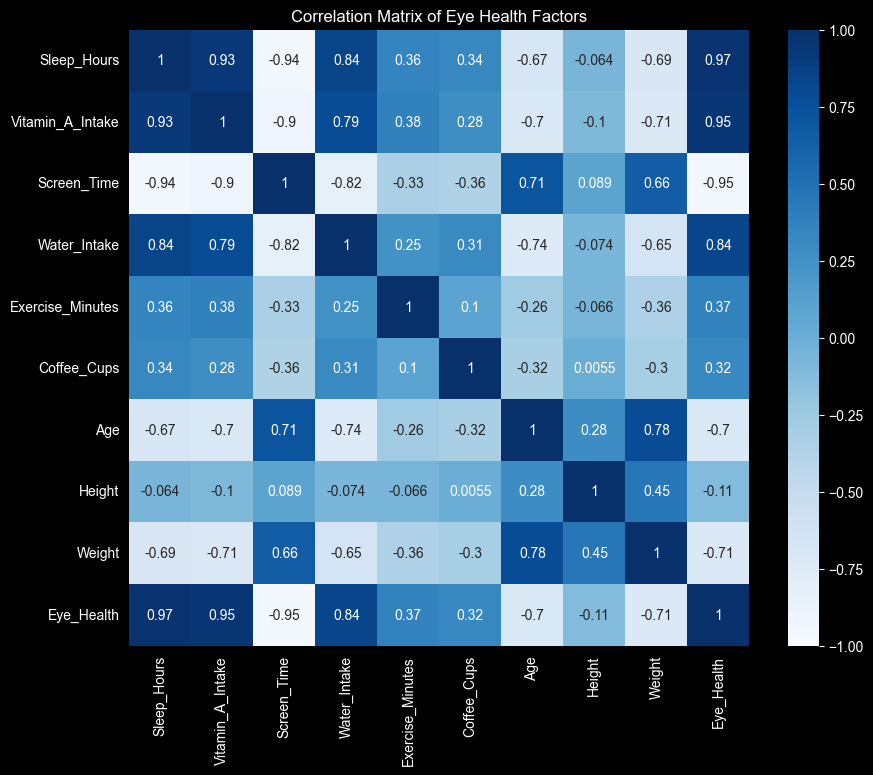

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('eyes.csv', skipinitialspace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

plt.figure(figsize=(10,8))
corrmatrix = df.corr()
sns.heatmap(corrmatrix, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Eye Health Factors')
plt.show()

In [15]:
target = 'Eye_Health'
features = [col for col in df.columns if col != target]

bestr2 = -1
bestfeatures = []

while len(features) > 0:
    x = df[features]
    y = df[target]
    
    xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(xtrain, ytrain)
    
    predictions = model.predict(xtest)
    currentr2 = r2_score(ytest, predictions)
    
    if currentr2 > bestr2:
        bestr2 = currentr2
        bestfeatures = features.copy()
    
    correlations = df[features].corrwith(df[target]).abs()
    worstfeature = correlations.idxmin()
    features.remove(worstfeature)

print("Best R2 Score:", bestr2)
print("Selected Features:", bestfeatures)

bestfit = df[bestfeatures + [target]]
bestfit.to_csv('bestfit.csv', index=False)

Best R2 Score: 0.9468416180983615
Selected Features: ['Sleep_Hours', 'Vitamin_A_Intake']


In [16]:
x = df[bestfeatures]
y = df[target]

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)
finalmodel = LinearRegression()
finalmodel.fit(xtrain, ytrain)

finalpreds = finalmodel.predict(xtest)
print("Final R2:", r2_score(ytest, finalpreds))
print("Final MSE:", mean_squared_error(ytest, finalpreds))

Final R2: 0.9468416180983615
Final MSE: 0.8228540062407478


In [17]:
sampledata = xtest.iloc[:5]
actualvalues = ytest.iloc[:5]
predictedvalues = finalmodel.predict(sampledata)

comparison = pd.DataFrame({
    'Actual': actualvalues,
    'Predicted': predictedvalues
})
print(comparison)

    Actual  Predicted
0       72  71.330127
5       66  67.415912
46      73  73.836711
31      72  70.968119
13      70  69.305951
